This tutorial will show you how to run an example MCMC with Zeus21, and get constraints. As usual, let's import the packages of import (Zeus, numpy, class)

In [35]:
import zeus21
from matplotlib import pyplot as plt
import numpy as np
import emcee
import corner 


#set up the CLASS cosmology
from classy import Class
ClassCosmo = Class()
ClassCosmo.compute()
import eplots
import importlib
importlib.reload(eplots)
Plotting = eplots.Plotting()

All that will not be modified, whether you vary astro, cosmo, or both types of parameters.

Now, if you want to run an MCMC over astro params only things get easier, you can run cosmology once (which is expensive!) and then just vary astrophysics.

In [2]:
omega_b, omega_cdm = 0.022, 0.12
CosmoParams_input = zeus21.Cosmo_Parameters_Input(omegab=omega_b,omegac = omega_cdm, zmin_CLASS=0.0) #make sure to provide zmin_CLASS lower than standard (5.0) if you want lower z results (eg HMFs)
#define all cosmology (including derived) parameters, and save them to the CosmoParams structure

CosmoParams,ClassyCosmo, CorrFclass ,HMFintclass =  zeus21.cosmo_wrapper(CosmoParams_input)
print('Cosmology part is done -- now do astrophysics.')

Cosmology part is done -- now do astrophysics.


In Zeus you're expected to pass a dictionary to predict observables (eg UVLFs, 21cm power spectrum, or global signal.) We have to build a lil' wrapper around that for doing an MCMC with emcee. Here's an example varying the 4 halo-galaxy connection parameters (SFR as a function of Mgdot, as in 2306.09403):

In [3]:
def param_wrapper(paramvector):
    'Input params are log10eps, log10Mc, a*, b*, for ease of sampling'
    log10epsstar, log10Mcstar, alphastar, betastar = paramvector
    astroparams = zeus21.Astro_Parameters(CosmoParams,epsstar=10**log10epsstar, Mc=10**log10Mcstar,alphastar=alphastar, betastar=betastar) 
    
    return astroparams


def UVLF_wrapper(zcenters, zwidths, MUVcenters, MUVwidths, paramvector):
    'Computes and returns the UVLF at z=zcenters, with width zwidths, in bins centered at MUVcenters with width MUVwidths'
    'Output is PhiUV, depends on astro parameter inputs paramvector'
    astroparams = param_wrapper(paramvector)
    UVLFs_std = zeus21.UVLFs.UVLF_binned(astroparams,CosmoParams,HMFintclass,zcenters,zwidths,MUVcenters,MUVwidths)
    return UVLFs_std

Let's try it out and plot for a couple of parameters

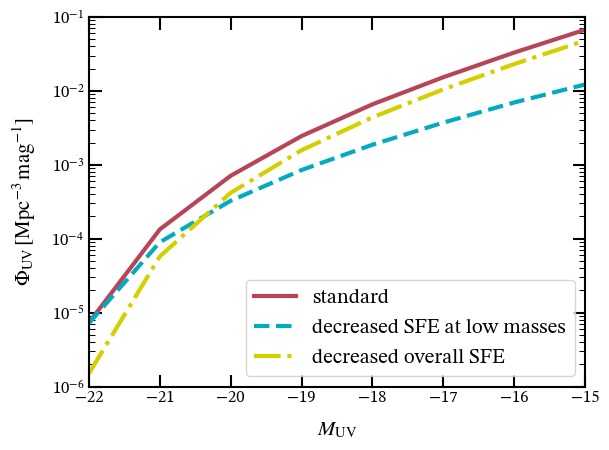

In [10]:
z, dz = 5.0, 0.5 #zcentral and width (assumed Gaussian)
MUVs = 1.0*np.arange(-13,-23,-1) #centers of bins
dMUVs = -np.diff(MUVs); dMUVs = np.append(dMUVs,dMUVs[-1]) # This is MUVwidths (just the difference between each step

params1 = [-1.0,12.0,0.5,-1.] #log(epsilon_0), log(M_critical), alpha, beta
UVLF1 = UVLF_wrapper(z,dz,MUVs,dMUVs, params1)

params2 = [-1.0,12.0,1.,-1.]
UVLF2 = UVLF_wrapper(z,dz,MUVs,dMUVs, params2)

params3 = [-1.2,12.0,0.5,-1.]
UVLF3 = UVLF_wrapper(z,dz,MUVs,dMUVs, params3)

plt.semilogy(MUVs, UVLF1, label = 'standard')
plt.semilogy(MUVs, UVLF2, linestyle = '--', label = 'decreased SFE at low masses')
plt.semilogy(MUVs, UVLF3,linestyle = '-.', label = 'decreased overall SFE')

plt.xlim(-22,-15)
plt.ylim(1e-6,1e-1)
plt.xlabel(r'$M_{\rm UV}$');
plt.ylabel(r'$\Phi_{\rm UV}\,\rm [Mpc^{-3}\,mag^{-1}]$')
plt.legend()

In [11]:
#just to test how fast it is to run 1 iteration of UVLF, <1ms when doing astro only (per z)
for i in range (1000):
    UVLF3 = UVLF_wrapper(z,dz,MUVs,dMUVs, params3)

Now let us read the data we will MCMC against. We use the UVLF measured by Bouwens+21 (LINK), compiled in GALLUMI (LINK).


In [20]:
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    print(z)
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

4.0
5.0
6.0
7.0
8.0
9.0
10.0


In [21]:
datHST

[[4.0,
  0.5,
  array([-22.69, -22.19, -21.69, -21.19, -20.69, -20.19, -19.69, -19.19,
         -18.69, -17.94, -16.94, -15.94]),
  array([5.000e-06, 1.500e-05, 1.440e-04, 3.440e-04, 6.980e-04, 1.624e-03,
         2.276e-03, 3.056e-03, 4.371e-03, 1.016e-02, 2.742e-02, 2.882e-02]),
  array([4.00e-06, 9.00e-06, 2.20e-05, 3.80e-05, 6.80e-05, 1.31e-04,
         1.99e-04, 3.88e-04, 6.89e-04, 9.20e-04, 3.44e-03, 8.74e-03]),
  array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])],
 [5.0,
  0.5,
  array([-23.11, -22.61, -22.11, -21.61, -21.11, -20.61, -20.11, -19.61,
         -19.11, -18.36, -17.36, -16.36]),
  array([1.000e-06, 4.000e-06, 2.800e-05, 9.200e-05, 2.620e-04, 5.840e-04,
         8.790e-04, 1.594e-03, 2.159e-03, 4.620e-03, 8.780e-03, 2.512e-02]),
  array([1.00e-06, 2.00e-06, 7.00e-06, 1.30e-05, 2.40e-05, 4.40e-05,
         6.70e-05, 1.56e-04, 3.46e-04, 5.20e-04, 1.54e-03, 7.34e-03]),
  array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])],
 [6.0,
  0.5

In [23]:
MINRELERROR = 0.2 #min relative error in UVLF, assumed from cosmic variance and systematics

def log_prior(paramvector):
    'Modify this to whichever params youre varying'

    log10epsstar, log10Mcstar, alphastar, betastar = paramvector
    
    if (log10epsstar>1.0 or log10epsstar<-5.0):
        return -np.inf  
    elif (log10Mcstar>15 or log10Mcstar<10):
        return -np.inf  
    elif (alphastar<0.0 or alphastar>3.0):
        return -np.inf
    elif (betastar>0 or betastar<-3.0):
        return -np.inf
    else:
        return 0.0
  
    
def log_like(paramvector, datavector):
    'Sample flat in eps, alph, beta, and log10Mc. datavector has all the z and UVLF data'
    
    #now bin it appropriately at each z -- data part
    loglike_curr = 0.0

    for dataarrayz in datavector: # Add the log likelihoods together for each redshift. The log likelihood is just a sum over all the points
        # anyways, so this makes sense
        #datHSTz4=[3.8, mags_z4,phi_z4,err_z4,errx_z4]
        zdat = dataarrayz[0]
        zerr = dataarrayz[1]
        xdat = dataarrayz[2]
        ydat = dataarrayz[3]
        yerr = dataarrayz[4] 
        xerr = dataarrayz[5]                
        #izus = np.argmin(np.abs(z0list - zdat))      
        
        yerr = np.fmax(yerr, ydat*MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above
                    
        uvlftheory = UVLF_wrapper(zdat,zerr,xdat,xerr, paramvector)
        
        loglike_curr += -np.sum( (ydat - uvlftheory)**2/(2.0 * yerr**2) ) #assumed Gaussian, to be revisited.
    
    return loglike_curr


def log_prob(paramvector, datavector):
    
    lprior=log_prior(paramvector)
    if (lprior > -np.inf): #only run if in prior range. avoid weird behavior for negative logs etc
        lpost=log_like(paramvector, datavector)
    else:
        lpost = 0.0 #doesn't matter, added to -inf
    return lprior + lpost

In [24]:
print(log_prior(params1))
print(log_like(params1,datHST))
print(log_prob(params1,datHST))

0.0
-217.64413850451768
-217.64413850451768


/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


Now that we know it works let's run the MCMC!

In [25]:
ndim = len(params1)
nwalkers = 2*ndim

p0 = (1 + np.random.rand(nwalkers, ndim) * 2) * params1
#trim p0 of walkers that are outside of prior range
for ip,pval in enumerate(p0):
    priorval = log_prior(p0[ip]) 
    while(priorval<0.0):
        p0[ip] = (1 + np.random.rand(ndim) * 2) * params1
        priorval = log_prior(p0[ip])   


sampler_hst = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[datHST])
state_hst = sampler_hst.run_mcmc(p0, 100)
sampler_hst.reset()      

Run a quick MCMC with ~1e5 points (~1e4 Nsteps x ~10 walkers). Should take ~3 mins.

In [38]:
Nsteps=2000
import time
tic=time.time()
sampler_hst.run_mcmc(state_hst, Nsteps);
toc=time.time()
print(toc-tic)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


17.194427967071533


In [39]:
burnin=400
samples_hst = sampler_hst.get_chain(flat=True)[burnin:]

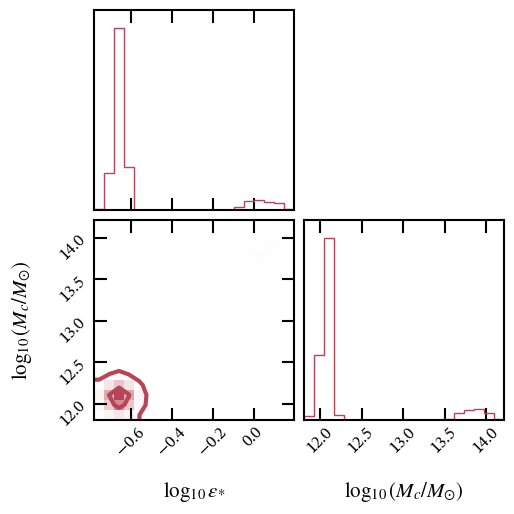

In [40]:
#corner for params[0] and params[1]
legendhere = ["$\\log_{10}\\epsilon_{*}$","$\\log_{10}(M_{c}/M_{\\odot})$"]
sigmalevels = [(1 - np.exp(-1*0.5)),(1 - np.exp(-4*0.5))]

_log10epssamples = samples_hst[:,0]
_log10Mcsamples = samples_hst[:,1]

figeps = corner.corner(np.array([_log10epssamples,_log10Mcsamples]).T, color=Plotting.red,alpha=0.2,
smooth=1.0,plot_datapoints=False, levels=sigmalevels, labels=legendhere)


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_86215/1773285006.py:2: SyntaxWarning: invalid escape sequence '\s'
  legendhere = ["$\\log_{10}\\epsilon_{*}$","$\\alpha_\star$"]


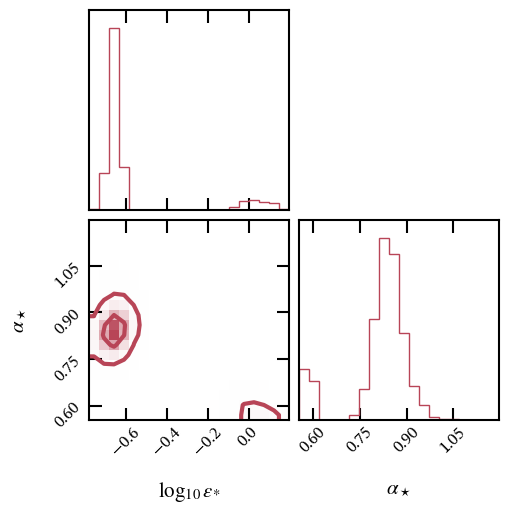

In [41]:
#corner for params[0] and params[2]
legendhere = ["$\\log_{10}\\epsilon_{*}$","$\\alpha_\star$"]
sigmalevels = [(1 - np.exp(-1*0.5)),(1 - np.exp(-4*0.5))]

_log10epssamples = samples_hst[:,0]
_alphasamples = samples_hst[:,2]

figeps = corner.corner(np.array([_log10epssamples,_alphasamples]).T, color=Plotting.red,alpha=0.2,
smooth=1.0,plot_datapoints=False, levels=sigmalevels, labels=legendhere)

Now you're ready to run MCMCs and get parameter constraints! But before you use this in papers, note that this is a simple z-independent model and may be missing bells and whistles. Check <<LINK>> for a more realistic model that you can implement